In [1]:
%config InlineBackend.figure_formats=['svg']
%load_ext autoreload
%autoreload 2

# Generic packages
import numpy as np 
from os import listdir


# Machine Learning
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.cluster import KMeans, MiniBatchKMeans


from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from tqdm.notebook import tqdm

from numpy import trapz
from scipy.signal import savgol_filter
import torch


from AutoencoderAPI.utils.files import open_object
from AutoencoderAPI.utils.plot import plot_hist
from AutoencoderAPI import autoencoder as auto

### Functions

#### Load traces

In [2]:
class build_dataset:
    def __init__(self, config):
        """
        # __init(config)__

        __init(config)__

            Define parameters to access the dataset

        Parameters
        ----------
            -config (dict) : Parameters (path, signal_size, batch_number) 

        Returns
        -------
            - None
        """
        self.files = listdir(config['path'])
        self.path = config['path']
        self.signal_size = config['signal_size']

        if config['batch_number'] > len(self.files):
            print(f'Batch number too large, was set to {len(self.files)}')
            config['batch_number'] = len(self.files)

        self.batch_split = np.array_split(self.files, config['batch_number'])


    def __getitem__(self,index):
        """
        
        """
        batch = self.batch_split[index]
    
        X = np.concatenate([np.fromfile(f"{self.path}{fileName}",dtype=np.float16).reshape(-1,self.signal_size) for fileName in batch])
    
        return X

In [3]:
class compare:

    def __init__(self, config):
        
        self.dataset = build_dataset(config)
        self.config = config


    def silhouette_kmean(X_list, Title, max_cluster, skip):

        for index, X in enumerate(X_list):

            if skip > 1:
                X = X[::10]

            X = (X - np.min(X)) / (np.max(X) - np.min(X)) 
            X = np.array(X).reshape(-1,1)

            eval_cluster = range(4,max_cluster+1)
            scores = np.zeros((len(X_list) , len(eval_cluster)))
            
            for cluster_index, cluster_number in tqdm(enumerate(eval_cluster) , desc="Clusters") :
                clusters = MiniBatchKMeans(n_clusters=cluster_number, random_state=42, init="k-means++", n_init='auto', batch_size=4096).fit_predict(X)
                scores[index, cluster_index] = silhouette_score(X, clusters)

        return eval_cluster, scores



    def max_value(self):

        #X_filter = savgol_filter(self.dataset.__getitem__(0), 20, 2)
        feature = np.max(self.dataset.__getitem__(0), axis=1)
        
        if self.config['batch_number'] > 1:
            for batch_index in range(1, self.config['batch_number']):

                X_filter = savgol_filter(self.dataset.__getitem__(batch_index), 20, 2)
                feature = np.append(feature, np.max(X_filter, axis=1))

        return feature

    

    def area(self):

        #X_filter = savgol_filter(self.dataset.__getitem__(0), 20, 2)
        feature = trapz(self.dataset.__getitem__(0), dx=1)
        
        if self.config['batch_number'] > 1:
            for batch_index in range(1, self.config['batch_number']):

                X_filter = savgol_filter(self.dataset.__getitem__(batch_index), 20, 2) 
                feature = np.append(feature, trapz(X_filter, dx=1))

        return feature


    def principal_component(self):

        pca = IncrementalPCA(n_components=1, batch_size=100)
        feature = pca.fit_transform(self.dataset.__getitem__(0))

        return feature

    
    def autoencoder(self, model):

        path = f"Autoencoder Log/{model}"
        config_load = open_object(f"{path}/log.bin")

        network = auto.build_autoencoder(config_load)
        network.load_state_dict(torch.load(f"{path}/model.pt"))
        network.eval()

        X_pytorch = torch.from_numpy(self.dataset.__getitem__(0)).view(-1, 1, config_load['files']['input_dimension']).float()
        feature = network(X_pytorch, encoding=True).detach().numpy().reshape(-1)

        return feature



    

In [4]:
config = {
    'path'         : "Datasets/NIST 1 (short)/", 
    'signal_size'  : 800,
    'batch_number' : 1
}

### Experiments

In [5]:
comp = compare(config)

In [6]:
feature_MV = comp.max_value()

In [7]:
feature_AR = comp.area()

In [8]:
feature_PCA = comp.principal_component()

In [9]:
#feature_AUTO = comp.autoencoder(model='run-2023-08-09-08-35/fold 0')

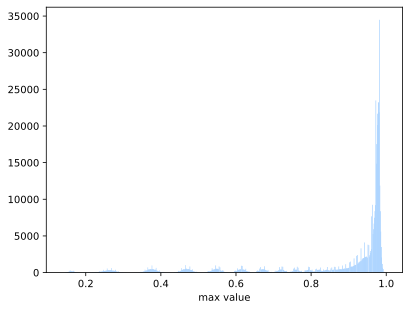

In [10]:
plot_hist(feature_MV, "max value")

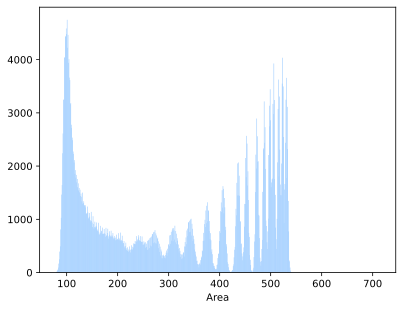

In [11]:
plot_hist(feature_AR, "Area")

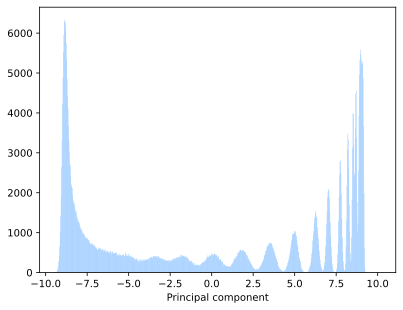

In [12]:
plot_hist(feature_PCA, "Principal component")